In [5]:
# Step 1 : Import all important Liabraries

In [6]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

In [7]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/Brain Tumor Classification using CNN/Data/Training'
test_dir = '/content/drive/MyDrive/Brain Tumor Classification using CNN/Data/Testing'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [8]:
# Data Visulation

/tmp/ipython-input-841300863.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=train_counts, ax=axes[0], palette='viridis')
/tmp/ipython-input-841300863.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=test_counts, ax=axes[1], palette='viridis')


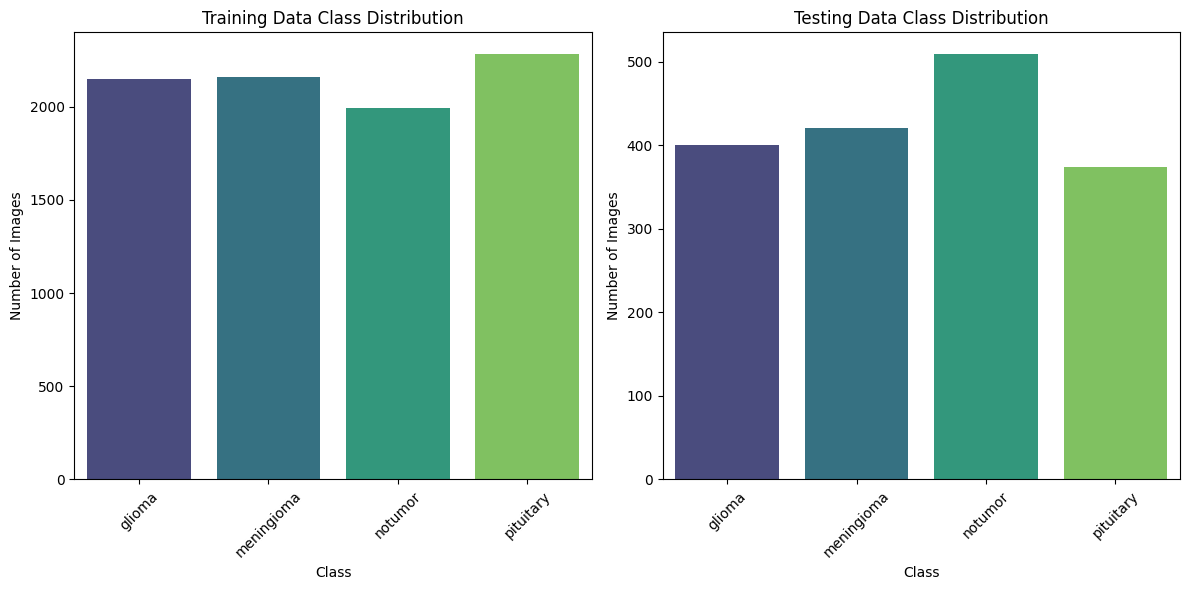

In [25]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.utils import shuffle

# Load ad shuffle the train data (Redefine as it was not accessible)
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data (Redefine as it was not accessible)
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


# Count the occurrences of each class label
train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

# Get class names from the training directory (assuming both train and test have same classes)
class_names = os.listdir(train_dir)

# Sort class names for consistent plotting order
class_names.sort()

# Create lists for plotting
train_counts = [train_class_counts[name] for name in class_names]
test_counts = [test_class_counts[name] for name in class_names]

# Create a figure with two subplots (one for train, one for test)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Training Data
sns.barplot(x=class_names, y=train_counts, ax=axes[0], palette='viridis')
axes[0].set_title('Training Data Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

# Plot for Testing Data
sns.barplot(x=class_names, y=test_counts, ax=axes[1], palette='viridis')
axes[1].set_title('Testing Data Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability


plt.tight_layout()
plt.show()

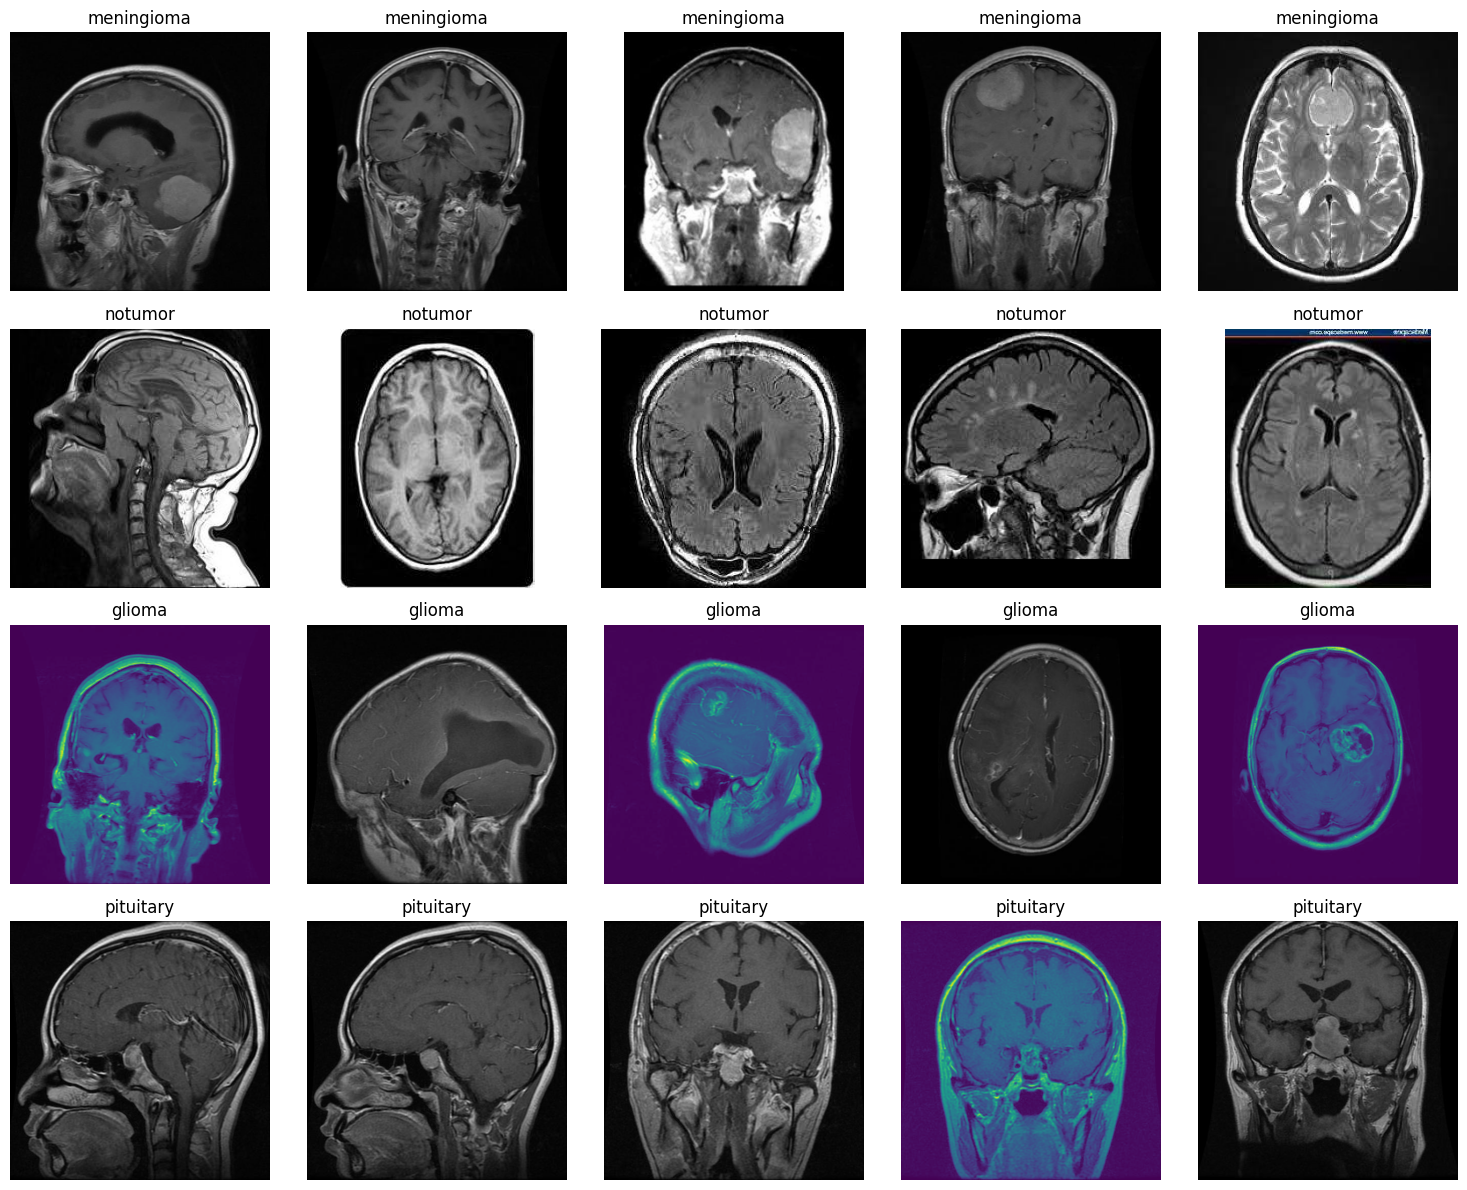

In [9]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os
from sklearn.utils import shuffle # Need to import shuffle again for this block

# Load and shuffle the train data (Redefine as it was not accessible)
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)


def display_sample_images(image_paths, image_labels, class_names, num_samples_per_class=5):
    """
    Displays a grid of sample images from each class.

    Args:
        image_paths (list): List of image file paths.
        image_labels (list): List of corresponding image labels.
        class_names (list): List of unique class names.
        num_samples_per_class (int): Number of sample images to display for each class.
    """
    plt.figure(figsize=(15, len(class_names) * 3))
    for i, class_name in enumerate(class_names):
        # Get indices for the current class
        class_indices = [j for j, label in enumerate(image_labels) if label == class_name]
        # Select random sample indices
        sample_indices = random.sample(class_indices, min(num_samples_per_class, len(class_indices)))

        for k, sample_index in enumerate(sample_indices):
            plt.subplot(len(class_names), num_samples_per_class, i * num_samples_per_class + k + 1)
            img_path = image_paths[sample_index]
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Get unique class names from the training directory
class_names = os.listdir(train_dir)

# Display sample images from the training data
display_sample_images(train_paths, train_labels, class_names)

In [10]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [11]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 40
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 10

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1388s 6s/step - loss: 0.6590 - sparse_categorical_accuracy: 0.7280
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1396s 7s/step - loss: 0.1985 - sparse_categorical_accuracy: 0.9240
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1377s 6s/step - loss: 0.1277 - sparse_categorical_accuracy: 0.9485
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1393s 7s/step - loss: 0.0873 - sparse_categorical_accuracy: 0.9660
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1402s 7s/step - loss: 0.0529 - sparse_categorical_accuracy: 0.9788
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1375s 6s/step - loss: 0.0575 - sparse_categorical_accuracy: 0.9801
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1377s 6s/step - loss: 0.0212 - sparse_categorical_accuracy: 0.9943
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1385s 6s/step - loss: 0.0173 - sparse_categorical_accuracy: 0.9950
Epoch 9/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 1377s 6s/step - loss: 0.0447 - sparse_categorical_accuracy: 0.9832
Epoch 10/10
214/214 ━━━━━━━━━━━━━━━━━

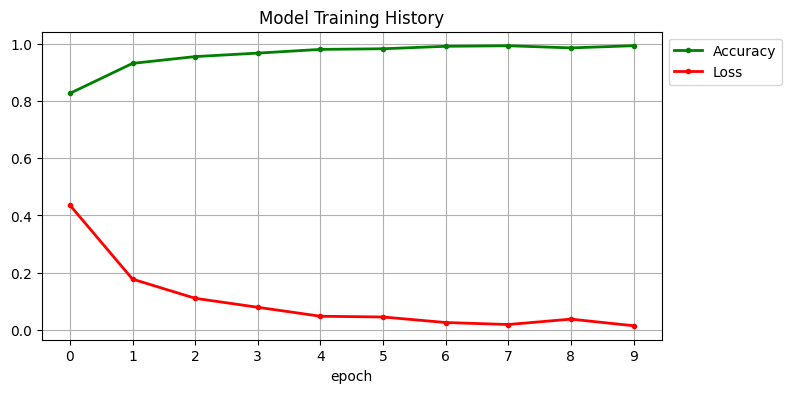

In [12]:
import matplotlib.pyplot as plt # Add the import statement

plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


54/54 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       421
           1       0.96      0.98      0.97       510
           2       0.97      0.80      0.88       400
           3       0.96      0.93      0.94       374

    accuracy                           0.92      1705
   macro avg       0.93      0.92      0.92      1705
weighted avg       0.93      0.92      0.92      1705



Confusion Matrix:
[[408   0   7   6]
 [  3 501   0   6]
 [ 64  11 321   4]
 [ 16  10   2 346]]


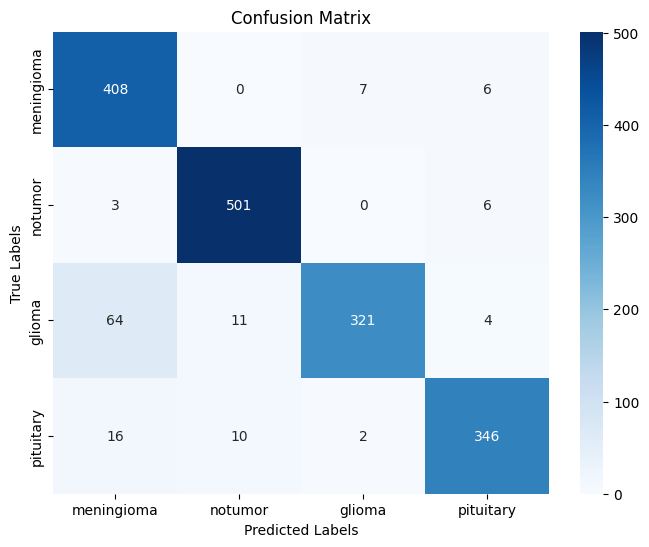

In [14]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

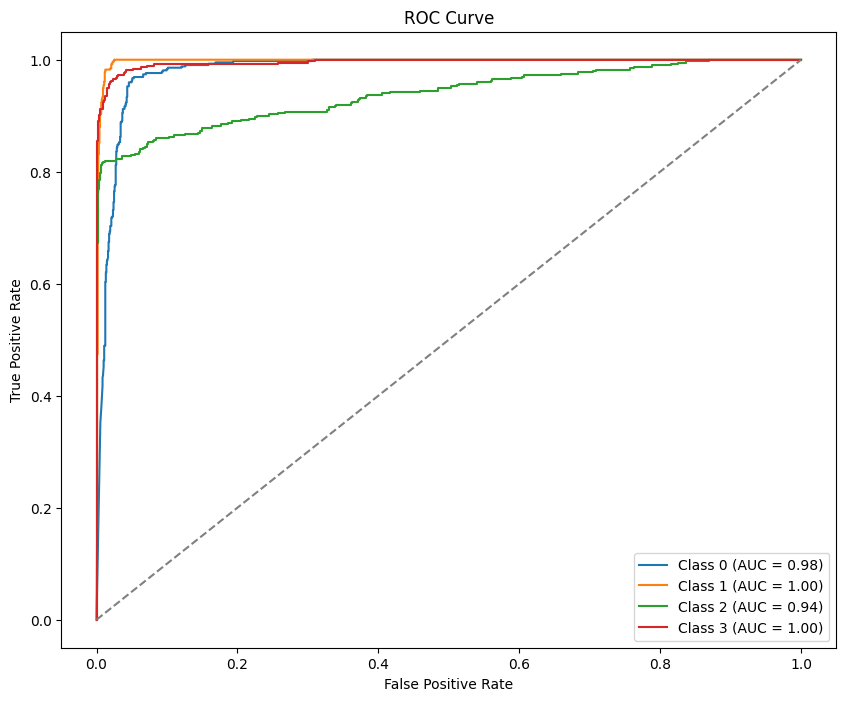

In [15]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [16]:
# Save the entire model
model.save('model.h5')

In [17]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [18]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


In [19]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Error processing the image: [Errno 2] No such file or directory: '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-meTr_0001.jpg'


In [20]:

# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Error processing the image: [Errno 2] No such file or directory: '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-noTr_0004.jpg'


In [21]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-piTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Error processing the image: [Errno 2] No such file or directory: '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-piTr_0003.jpg'


In [22]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Error processing the image: [Errno 2] No such file or directory: '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0015.jpg'
